# EDA 
This notebook explores the data evailable transit data for further development


## Packages

In [1]:
import os 
from google.transit import gtfs_realtime_pb2
import requests
from requests.exceptions import Timeout, ConnectionError, HTTPError
from time import sleep
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from typing import Optional, List
import mysql.connector
import geopandas as gpd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Constants

In [2]:
realtime_vehicle_updates_url = "https://bct.tmix.se/gtfs-realtime/vehicleupdates.pb?operatorIds=47"

root_dir = os.path.dirname(os.path.abspath("."))  # Fixed typo from dirname to dir
data_dir = os.path.join(root_dir, "data")
src_dir = os.path.join(root_dir, "src")
os.makedirs(data_dir, exist_ok=True)

df_path = os.path.join(data_dir, "vehicle_updates.csv")
df_bus_stop_path = os.path.join(data_dir, "Kelowna_Regional_Transit_System_stops.csv")

## Fetch data 

In [3]:


conn = mysql.connector.connect(
    host="localhost",
    user="transit",
    password="transit123",
    database="transitdb",
    port=3307
)

df_fetch = pd.read_sql("SELECT * FROM TRANSIT_DATA", conn)
df_vehicle_updates = pd.read_sql("SELECT * FROM TRANSIT_VEHICLE_TABLE", conn)
df_trip_updates = pd.read_sql("SELECT * FROM TRANSIT_TRIP_TABLE", conn)
conn.close()

df_bus_stop = pd.read_csv(df_bus_stop_path)
rename_cols = df_bus_stop.columns.tolist()[1:]
df_bus_stop.rename(columns=
            {col: col+"_stop" for col in rename_cols}, inplace=True)

/tmp/ipykernel_11381/1992504509.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fetch = pd.read_sql("SELECT * FROM TRANSIT_DATA", conn)
/tmp/ipykernel_11381/1992504509.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_vehicle_updates = pd.read_sql("SELECT * FROM TRANSIT_VEHICLE_TABLE", conn)
/tmp/ipykernel_11381/1992504509.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trip_updates = pd.read_sql("SELECT * FROM TRANSIT_TRIP_TABLE", conn)


## EDA supervised data set

In [20]:
df_vehicle_updates

df_vu_bus8 = df_vehicle_updates[df_vehicle_updates['trip_route_id'] == '8-KEL']

In [19]:
df_vu_bus8['trip_id'].value_counts()

trip_id
2848453:11789026:11792102    762
2848464:11777429:11790651    747
2848426:11782636:11791336    696
2848437:11778110:11791137    684
2848444:11774180:11791336    682
                            ... 
2846689:11775052:11792127     14
2846702:11786913:11791605      8
2846682:11787336:11791908      7
2846734:11777791:11792012      3
2846763:11777442:11790702      2
Name: count, Length: 164, dtype: int64

In [8]:
df_vu_trip = df_vu_bus8[df_vu_bus8['trip_id'] == '2848724:12452072:12455697']

In [10]:
df_vu_trip['trip_start_timestamp'].value_counts()

trip_start_timestamp
2026-02-22 14:50:00    210
2026-02-15 14:50:00    195
2026-02-16 14:50:00    192
Name: count, dtype: int64

In [13]:
df_vu_trip_singular = df_vu_trip[df_vu_trip['trip_start_timestamp'] == '2026-02-22 14:50:00']

In [14]:
df_vu_trip_singular

,id,feed_timestamp,entity_id,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,position_latitude,position_longitude,position_bearing,...,position_speed,current_stop_sequence,current_status,timestamp,congestion_level,stop_id,vehicle_id,vehicle_label,trip_start_timestamp,read_timestamp
188363,188364,2026-02-22 22:34:18,6,2848724:12452072:12455697,0,8-KEL,1,49.939518,-119.394318,0.000000,...,0.00,1,2,2026-02-22 22:34:03,1,140101,3131329277,3131329277,2026-02-22 14:50:00,2026-02-22 22:34:21
188422,188423,2026-02-22 22:35:07,6,2848724:12452072:12455697,0,8-KEL,1,49.939514,-119.394318,0.000000,...,0.00,1,2,2026-02-22 22:35:04,1,140101,3131329277,3131329277,2026-02-22 14:50:00,2026-02-22 22:35:09
188504,188505,2026-02-22 22:36:07,6,2848724:12452072:12455697,0,8-KEL,1,49.939514,-119.394310,0.000000,...,0.00,1,2,2026-02-22 22:36:06,1,140101,3131329277,3131329277,2026-02-22 14:50:00,2026-02-22 22:36:08
188524,188525,2026-02-22 22:36:22,6,2848724:12452072:12455697,0,8-KEL,1,49.939514,-119.394310,0.000000,...,0.00,1,2,2026-02-22 22:36:21,1,140101,3131329277,3131329277,2026-02-22 14:50:00,2026-02-22 22:36:24
188608,188609,2026-02-22 22:37:25,6,2848724:12452072:12455697,0,8-KEL,1,49.939514,-119.394310,0.000000,...,0.00,1,2,2026-02-22 22:37:22,1,140101,3131329277,3131329277,2026-02-22 14:50:00,2026-02-22 22:37:29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193471,193472,2026-02-22 23:39:39,6,2848724:12452072:12455697,0,8-KEL,1,49.861927,-119.488808,92.000000,...,6.94,46,2,2026-02-22 23:39:37,1,103020,3131329277,3131329277,2026-02-22 14:50:00,2026-02-22 23:39:40
193524,193525,2026-02-22 23:40:24,6,2848724:12452072:12455697,0,8-KEL,1,49.861851,-119.488297,107.699997,...,7.77,46,2,2026-02-22 23:40:21,1,103020,3131329277,3131329277,2026-02-22 14:50:00,2026-02-22 23:40:28
193545,193546,2026-02-22 23:40:39,6,2848724:12452072:12455697,0,8-KEL,1,49.861294,-119.486626,119.000000,...,14.16,46,2,2026-02-22 23:40:32,1,103020,3131329277,3131329277,2026-02-22 14:50:00,2026-02-22 23:40:44
193562,193563,2026-02-22 23:40:54,6,2848724:12452072:12455697,0,8-KEL,1,49.860912,-119.484894,0.000000,...,0.00,46,1,2026-02-22 23:40:52,1,103020,3131329277,3131329277,2026-02-22 14:50:00,2026-02-22 23:40:55


In [16]:
df_vu_trip_trim = df_vu_trip_singular
df_vu_trip_trim['arrival_delay'] = None
df_vu_trip_trim['departure_delay'] = None
df_vu_trip_trim['arrival_time'] = None
df_vu_trip_trim['departure_time'] = None
for i in range(len(df_vu_trip_trim)):
    row = df_vu_trip_trim.iloc[i]
    trip_id = row['trip_id']
    stop_id = row['stop_id']
    feed_timestamp = row['feed_timestamp']

    df_update = df_trip_updates[df_trip_updates['feed_timestamp'] <= feed_timestamp]
    df_update = df_update[df_update['trip_id']==trip_id]
    df_update = df_update[df_update['stop_id']==stop_id]
    if not df_update.empty:
        arrival_delay = df_update.iloc[-1]['arrival_delay']
        departure_delay = df_update.iloc[-1]['departure_delay']
        arrival_time = df_update.iloc[-1]['arrival_time']
        departure_time = df_update.iloc[-1]['departure_time']
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'arrival_delay'] = arrival_delay
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'departure_delay'] = departure_delay
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'arrival_time'] = arrival_time
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'departure_time'] = departure_time
    else:
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'arrival_delay'] = np.nan
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'departure_delay'] = np.nan
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'arrival_time'] = np.nan
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'departure_time'] = np.nan


/tmp/ipykernel_11381/2500237019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vu_trip_trim['arrival_delay'] = None
/tmp/ipykernel_11381/2500237019.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vu_trip_trim['departure_delay'] = None
/tmp/ipykernel_11381/2500237019.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

In [17]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_vu_trip_trim['feed_timestamp'],
    y=df_vu_trip_trim['arrival_delay'],
    mode='lines+markers',
    name='Arrival Delay',
    yaxis='y1',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=df_vu_trip_trim['feed_timestamp'],
    y=df_vu_trip_trim['current_stop_sequence'],
    mode='lines+markers',
    name='Stop Sequence',
    yaxis='y2',
    line=dict(color='orange')
))

fig.update_layout(
    xaxis=dict(title='Feed Timestamp'),
    yaxis=dict(title='Arrival Delay', title_font=dict(color='blue'), tickfont=dict(color='blue')),
    yaxis2=dict(
        title='Current Stop Sequence',
        title_font=dict(color='orange'),
        tickfont=dict(color='orange'),
        overlaying='y',
        side='right'
    ),
    legend=dict(x=0.01, y=0.01)
)

fig.show()

## Rough plots

In [58]:
df_vehicle_updates.groupby('trip_id')['feed_timestamp'].first().sort_values(ascending=True)[-10:]

trip_id
2847417:11773509:11792140   2026-02-12 03:56:06
2846324:11775898:11792204   2026-02-12 04:00:55
2846320:11778123:11791735   2026-02-12 04:03:46
2846487:11779002:11790798   2026-02-12 04:04:31
2846070:11782991:11790653   2026-02-12 04:06:35
2847177:11789598:11792058   2026-02-12 04:14:39
2846466:11779918:11790798   2026-02-12 04:14:39
2845970:11780342:12455833   2026-02-12 04:15:10
2846631:11773899:12455912   2026-02-12 04:17:58
2847372:11779064:12455774   2026-02-12 05:16:07
Name: feed_timestamp, dtype: datetime64[ns]

<Axes: >

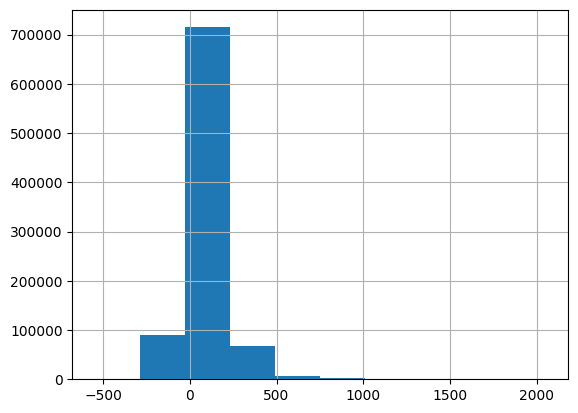

In [59]:
df_trip_updates['arrival_delay'].hist()

In [62]:
df_trip_updates[df_trip_updates['arrival_delay']>1000]

,id,feed_timestamp,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
297454,323982,2026-02-11 16:51:48,2846713:11788993:11791811,0,97-KEL,0,5,103745,0,1125,2026-02-11 16:54:45,0,1125,2026-02-11 16:54:45,0,2026-02-11 08:20:00
297455,323983,2026-02-11 16:51:48,2846713:11788993:11791811,0,97-KEL,0,6,102853,0,1125,2026-02-11 17:03:45,0,1035,2026-02-11 17:04:15,0,2026-02-11 08:20:00
297456,323984,2026-02-11 16:51:48,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1130,2026-02-11 17:07:50,0,1146,2026-02-11 17:08:06,0,2026-02-11 08:20:00
297457,323985,2026-02-11 16:51:48,2846713:11788993:11791811,0,97-KEL,0,8,140003,0,1100,2026-02-11 17:10:20,0,1117,2026-02-11 17:10:37,0,2026-02-11 08:20:00
297458,323986,2026-02-11 16:51:48,2846713:11788993:11791811,0,97-KEL,0,9,102985,0,1044,2026-02-11 17:12:24,0,1059,2026-02-11 17:12:39,0,2026-02-11 08:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396208,422736,2026-02-11 17:51:07,2846710:11775545:11791811,0,97-KEL,1,2,140113,0,1003,2026-02-11 17:53:43,0,1003,2026-02-11 17:53:43,0,2026-02-11 09:34:00
396209,422737,2026-02-11 17:51:07,2846710:11775545:11791811,0,97-KEL,1,3,103256,0,1003,2026-02-11 17:56:43,0,1003,2026-02-11 17:56:43,0,2026-02-11 09:34:00
396210,422738,2026-02-11 17:51:07,2846710:11775545:11791811,0,97-KEL,1,4,103049,0,1003,2026-02-11 18:00:43,0,1014,2026-02-11 18:00:54,0,2026-02-11 09:34:00
396294,422822,2026-02-11 17:51:07,2846730:11775049:11791665,0,97-KEL,0,13,140114,0,2026,2026-02-11 17:54:46,0,2026,2026-02-11 17:54:46,0,2026-02-11 08:35:00


In [63]:
df_trip_updates.trip_id[1450]

'2848800:11781588:11791884'

In [156]:
df_vu_bus_8 = df_vehicle_updates[df_vehicle_updates['trip_route_id'] == '8-KEL']

In [157]:
df_vu_bus_8_recent = df_vu_bus_8[df_vu_bus_8['feed_timestamp'] > '2026-02-10']

In [166]:
df_vu_bus_8_recent.trip_id.value_counts()

trip_id
2846958:12452145:12455698    168
2847025:11776941:12455850    152
2846957:12453583:12455644    141
2847024:11773127:12455848    133
2846959:12452788:12455848    119
2847026:11774725:12455644     91
2846956:12453601:12455850     46
2847023:11783436:12455698     33
2846960:12451033:12455850     24
2847027:11786792:12455698     22
Name: count, dtype: int64

In [78]:
#trip_id = '2848729:11776521:11791827'
trip_id = '2846957:12453583:12455644'
trip_id = '2846958:12452145:12455698'
trip_id = '2847026:11774725:12455644'
trip_id = '2846713:11788993:11791811'
trip_id = '2846730:11775049:11791665'

df_vu_trip = df_vehicle_updates[df_vehicle_updates['trip_id']==trip_id]
df_tu_trip = df_trip_updates[df_trip_updates['trip_id']==trip_id]

In [79]:
df_vu_trip

,id,feed_timestamp,entity_id,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,position_latitude,position_longitude,position_bearing,...,position_speed,current_stop_sequence,current_status,timestamp,congestion_level,stop_id,vehicle_id,vehicle_label,trip_start_timestamp,read_timestamp
46245,46246,2026-02-11 16:51:41,62,2846730:11775049:11791665,0,97-KEL,0,49.863216,-119.565643,0.000000,...,0.00,4,2,2026-02-11 16:51:24,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:51:56
46295,46296,2026-02-11 16:51:57,62,2846730:11775049:11791665,0,97-KEL,0,49.863216,-119.565636,0.000000,...,0.00,4,2,2026-02-11 16:51:55,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:52:03
46397,46398,2026-02-11 16:52:27,62,2846730:11775049:11791665,0,97-KEL,0,49.863216,-119.565636,0.000000,...,1.38,4,2,2026-02-11 16:52:25,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:52:31
46457,46458,2026-02-11 16:52:42,62,2846730:11775049:11791665,0,97-KEL,0,49.863216,-119.565636,0.000000,...,1.94,4,2,2026-02-11 16:52:27,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:52:47
46512,46513,2026-02-11 16:53:00,62,2846730:11775049:11791665,0,97-KEL,0,49.863220,-119.565636,0.000000,...,0.00,4,2,2026-02-11 16:52:59,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:53:03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57404,57405,2026-02-11 17:49:58,43,2846730:11775049:11791665,0,97-KEL,0,49.900269,-119.409637,30.299999,...,12.22,12,2,2026-02-11 17:49:52,1,103263,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 17:50:01
57443,57444,2026-02-11 17:50:13,43,2846730:11775049:11791665,0,97-KEL,0,49.901314,-119.408653,29.600000,...,9.44,12,2,2026-02-11 17:50:13,1,103263,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 17:50:17
57480,57481,2026-02-11 17:50:28,43,2846730:11775049:11791665,0,97-KEL,0,49.901684,-119.408310,32.599998,...,12.50,12,2,2026-02-11 17:50:17,1,103263,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 17:50:28
57523,57524,2026-02-11 17:50:43,43,2846730:11775049:11791665,0,97-KEL,0,49.902451,-119.407501,37.900002,...,1.94,12,1,2026-02-11 17:50:41,1,103263,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 17:50:44


In [80]:
min_trip_update_time = df_tu_trip['feed_timestamp'].min()
df_vu_trip_trim = df_vu_trip[df_vu_trip['feed_timestamp'] >= min_trip_update_time]
df_vu_trip_trim['arrival_delay'] = None
df_vu_trip_trim['departure_delay'] = None
df_vu_trip_trim['arrival_time'] = None
df_vu_trip_trim['departure_time'] = None

/tmp/ipykernel_1293/2979941255.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1293/2979941255.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1293/2979941255.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1293

In [81]:
for i in range(len(df_vu_trip_trim)):
    row = df_vu_trip_trim.iloc[i]
    trip_id = row['trip_id']
    stop_id = row['stop_id']
    feed_timestamp = row['feed_timestamp']

    df_update = df_tu_trip[df_tu_trip['feed_timestamp'] <= feed_timestamp]
    df_update = df_update[df_update['trip_id']==trip_id]
    df_update = df_update[df_update['stop_id']==stop_id]
    if not df_update.empty:
        arrival_delay = df_update.iloc[-1]['arrival_delay']
        departure_delay = df_update.iloc[-1]['departure_delay']
        arrival_time = df_update.iloc[-1]['arrival_time']
        departure_time = df_update.iloc[-1]['departure_time']
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'arrival_delay'] = arrival_delay
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'departure_delay'] = departure_delay
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'arrival_time'] = arrival_time
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'departure_time'] = departure_time
    else:
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'arrival_delay'] = np.nan
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'departure_delay'] = np.nan
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'arrival_time'] = np.nan
        df_vu_trip_trim.at[df_vu_trip_trim.index[i], 'departure_time'] = np.nan


In [82]:
df_vu_trip_trim

,id,feed_timestamp,entity_id,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,position_latitude,position_longitude,position_bearing,...,congestion_level,stop_id,vehicle_id,vehicle_label,trip_start_timestamp,read_timestamp,arrival_delay,departure_delay,arrival_time,departure_time
46295,46296,2026-02-11 16:51:57,62,2846730:11775049:11791665,0,97-KEL,0,49.863216,-119.565636,0.000000,...,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:52:03,344,344,2026-02-11 16:51:44,2026-02-11 16:51:44
46397,46398,2026-02-11 16:52:27,62,2846730:11775049:11791665,0,97-KEL,0,49.863216,-119.565636,0.000000,...,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:52:31,376,376,2026-02-11 16:52:16,2026-02-11 16:52:16
46457,46458,2026-02-11 16:52:42,62,2846730:11775049:11791665,0,97-KEL,0,49.863216,-119.565636,0.000000,...,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:52:47,407,407,2026-02-11 16:52:47,2026-02-11 16:52:47
46512,46513,2026-02-11 16:53:00,62,2846730:11775049:11791665,0,97-KEL,0,49.863220,-119.565636,0.000000,...,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:53:03,439,439,2026-02-11 16:53:19,2026-02-11 16:53:19
46619,46620,2026-02-11 16:53:30,62,2846730:11775049:11791665,0,97-KEL,0,49.863434,-119.564964,56.400002,...,3,140073,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 16:53:35,439,439,2026-02-11 16:53:19,2026-02-11 16:53:19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57404,57405,2026-02-11 17:49:58,43,2846730:11775049:11791665,0,97-KEL,0,49.900269,-119.409637,30.299999,...,1,103263,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 17:50:01,2009,2009,2026-02-11 17:50:29,2026-02-11 17:50:29
57443,57444,2026-02-11 17:50:13,43,2846730:11775049:11791665,0,97-KEL,0,49.901314,-119.408653,29.600000,...,1,103263,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 17:50:17,2009,2009,2026-02-11 17:50:29,2026-02-11 17:50:29
57480,57481,2026-02-11 17:50:28,43,2846730:11775049:11791665,0,97-KEL,0,49.901684,-119.408310,32.599998,...,1,103263,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 17:50:28,2009,2009,2026-02-11 17:50:29,2026-02-11 17:50:29
57523,57524,2026-02-11 17:50:43,43,2846730:11775049:11791665,0,97-KEL,0,49.902451,-119.407501,37.900002,...,1,103263,3131329239,3131329239,2026-02-11 08:35:00,2026-02-11 17:50:44,2009,2009,2026-02-11 17:50:29,2026-02-11 17:50:29


In [83]:
df_vu_trip_trim.iloc[-1]

id                                                57563
feed_timestamp                      2026-02-11 17:50:58
entity_id                                            43
trip_id                       2846730:11775049:11791665
trip_schedule_relationship                            0
trip_route_id                                    97-KEL
trip_direction_id                                     0
position_latitude                             49.903484
position_longitude                          -119.406738
position_bearing                                   30.0
position_odometer                               96643.0
position_speed                                    14.44
current_stop_sequence                                13
current_status                                        2
timestamp                           2026-02-11 17:50:55
congestion_level                                      1
stop_id                                          140114
vehicle_id                                   313

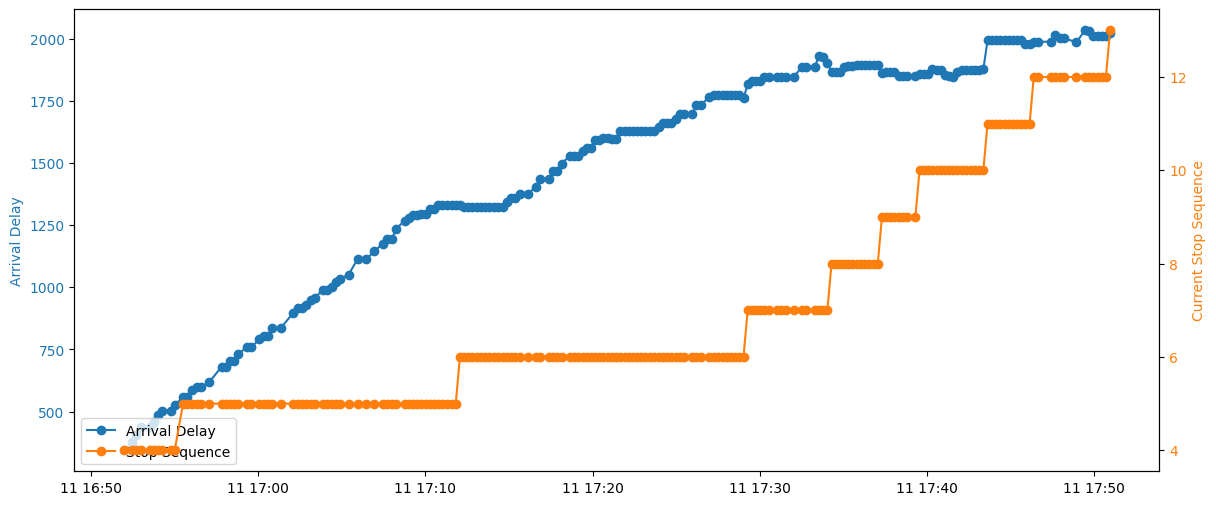

In [84]:
plt.figure(figsize=(14,6))
ax1 = plt.gca()
ax1.plot(df_vu_trip_trim['feed_timestamp'], df_vu_trip_trim['arrival_delay'], marker='o', color='tab:blue', label='Arrival Delay')
ax1.set_ylabel('Arrival Delay', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(df_vu_trip_trim['feed_timestamp'], df_vu_trip_trim['current_stop_sequence'], marker='o', color='tab:orange', label='Stop Sequence')
ax2.set_ylabel('Current Stop Sequence', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc='lower left')

In [71]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_vu_trip_trim['feed_timestamp'],
    y=df_vu_trip_trim['arrival_delay'],
    mode='lines+markers',
    name='Arrival Delay',
    yaxis='y1',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=df_vu_trip_trim['feed_timestamp'],
    y=df_vu_trip_trim['current_stop_sequence'],
    mode='lines+markers',
    name='Stop Sequence',
    yaxis='y2',
    line=dict(color='orange')
))

fig.update_layout(
    xaxis=dict(title='Feed Timestamp'),
    yaxis=dict(title='Arrival Delay', title_font=dict(color='blue'), tickfont=dict(color='blue')),
    yaxis2=dict(
        title='Current Stop Sequence',
        title_font=dict(color='orange'),
        tickfont=dict(color='orange'),
        overlaying='y',
        side='right'
    ),
    legend=dict(x=0.01, y=0.01)
)

fig.show()

In [72]:
stop_sequence_check = 12
df_vu_trip_trim[df_vu_trip_trim['current_stop_sequence']==stop_sequence_check]

,id,feed_timestamp,entity_id,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,position_latitude,position_longitude,position_bearing,...,congestion_level,stop_id,vehicle_id,vehicle_label,trip_start_timestamp,read_timestamp,arrival_delay,departure_delay,arrival_time,departure_time
54418,54419,2026-02-11 17:32:03,10,2846713:11788993:11791811,0,97-KEL,0,49.887070,-119.423920,42.400002,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:32:08,1902,1902,2026-02-11 17:35:42,2026-02-11 17:35:42
54461,54462,2026-02-11 17:32:18,10,2846713:11788993:11791811,0,97-KEL,0,49.888607,-119.421623,43.599998,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:32:19,1915,1915,2026-02-11 17:35:55,2026-02-11 17:35:55
54551,54552,2026-02-11 17:32:48,10,2846713:11788993:11791811,0,97-KEL,0,49.889011,-119.421051,0.000000,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:32:51,1915,1915,2026-02-11 17:35:55,2026-02-11 17:35:55
54637,54638,2026-02-11 17:33:18,10,2846713:11788993:11791811,0,97-KEL,0,49.889702,-119.420006,42.599998,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:33:23,1915,1915,2026-02-11 17:35:55,2026-02-11 17:35:55
54685,54686,2026-02-11 17:33:33,9,2846713:11788993:11791811,0,97-KEL,0,49.891163,-119.418198,36.200001,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:33:33,1947,1947,2026-02-11 17:36:27,2026-02-11 17:36:27
54727,54728,2026-02-11 17:33:48,9,2846713:11788993:11791811,0,97-KEL,0,49.892990,-119.416382,31.100000,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:33:49,1947,1947,2026-02-11 17:36:27,2026-02-11 17:36:27
54773,54774,2026-02-11 17:34:03,9,2846713:11788993:11791811,0,97-KEL,0,49.894238,-119.415268,31.100000,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:34:05,1925,1925,2026-02-11 17:36:05,2026-02-11 17:36:05
54814,54815,2026-02-11 17:34:18,9,2846713:11788993:11791811,0,97-KEL,0,49.896168,-119.413475,31.000000,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:34:21,1925,1925,2026-02-11 17:36:05,2026-02-11 17:36:05
54859,54860,2026-02-11 17:34:33,9,2846713:11788993:11791811,0,97-KEL,0,49.897724,-119.412018,30.799999,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:34:37,1925,1925,2026-02-11 17:36:05,2026-02-11 17:36:05
54899,54900,2026-02-11 17:34:48,9,2846713:11788993:11791811,0,97-KEL,0,49.899513,-119.410309,31.299999,...,1,103263,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:34:53,1904,1904,2026-02-11 17:35:44,2026-02-11 17:35:44


In [73]:
df_tu_trip_stop = df_tu_trip[df_tu_trip['stop_sequence'] == stop_sequence_check]
df_tu_trip_stop

,id,feed_timestamp,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
297461,323989,2026-02-11 16:51:48,2846713:11788993:11791811,0,97-KEL,0,12,103263,0,1114,2026-02-11 17:22:34,0,1144,2026-02-11 17:23:04,0,2026-02-11 08:20:00
300701,327229,2026-02-11 16:52:42,2846713:11788993:11791811,0,97-KEL,0,12,103263,0,1146,2026-02-11 17:23:06,0,1176,2026-02-11 17:23:36,0,2026-02-11 08:20:00
301985,328513,2026-02-11 16:53:19,2846713:11788993:11791811,0,97-KEL,0,12,103263,0,1177,2026-02-11 17:23:37,0,1207,2026-02-11 17:24:07,0,2026-02-11 08:20:00
303387,329915,2026-02-11 16:53:55,2846713:11788993:11791811,0,97-KEL,0,12,103263,0,1208,2026-02-11 17:24:08,0,1238,2026-02-11 17:24:38,0,2026-02-11 08:20:00
304508,331036,2026-02-11 16:54:31,2846713:11788993:11791811,0,97-KEL,0,12,103263,0,1239,2026-02-11 17:24:39,0,1269,2026-02-11 17:25:09,0,2026-02-11 08:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373606,400134,2026-02-11 17:31:51,2846713:11788993:11791811,0,97-KEL,0,12,103263,0,1902,2026-02-11 17:35:42,0,1902,2026-02-11 17:35:42,0,2026-02-11 08:20:00
374067,400595,2026-02-11 17:32:09,2846713:11788993:11791811,0,97-KEL,0,12,103263,0,1915,2026-02-11 17:35:55,0,1915,2026-02-11 17:35:55,0,2026-02-11 08:20:00
375524,402052,2026-02-11 17:33:22,2846713:11788993:11791811,0,97-KEL,0,12,103263,0,1947,2026-02-11 17:36:27,0,1947,2026-02-11 17:36:27,0,2026-02-11 08:20:00
376300,402828,2026-02-11 17:33:58,2846713:11788993:11791811,0,97-KEL,0,12,103263,0,1925,2026-02-11 17:36:05,0,1925,2026-02-11 17:36:05,0,2026-02-11 08:20:00


In [74]:
delta = 5
df_tu_trip_stop_m_delta = df_tu_trip[df_tu_trip['stop_sequence'] == stop_sequence_check - delta]
df_tu_trip_stop_m_delta

,id,feed_timestamp,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
297456,323984,2026-02-11 16:51:48,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1130,2026-02-11 17:07:50,0,1146,2026-02-11 17:08:06,0,2026-02-11 08:20:00
300696,327224,2026-02-11 16:52:42,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1162,2026-02-11 17:08:22,0,1178,2026-02-11 17:08:38,0,2026-02-11 08:20:00
301980,328508,2026-02-11 16:53:19,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1193,2026-02-11 17:08:53,0,1209,2026-02-11 17:09:09,0,2026-02-11 08:20:00
303382,329910,2026-02-11 16:53:55,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1224,2026-02-11 17:09:24,0,1240,2026-02-11 17:09:40,0,2026-02-11 08:20:00
304503,331031,2026-02-11 16:54:31,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1255,2026-02-11 17:09:55,0,1271,2026-02-11 17:10:11,0,2026-02-11 08:20:00
305763,332291,2026-02-11 16:55:07,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1287,2026-02-11 17:10:27,0,1303,2026-02-11 17:10:43,0,2026-02-11 08:20:00
307038,333566,2026-02-11 16:55:43,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1316,2026-02-11 17:10:56,0,1332,2026-02-11 17:11:12,0,2026-02-11 08:20:00
309010,335538,2026-02-11 16:56:37,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1347,2026-02-11 17:11:27,0,1363,2026-02-11 17:11:43,0,2026-02-11 08:20:00
309640,336168,2026-02-11 16:56:55,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1373,2026-02-11 17:11:53,0,1389,2026-02-11 17:12:09,0,2026-02-11 08:20:00
310286,336814,2026-02-11 16:57:13,2846713:11788993:11791811,0,97-KEL,0,7,140049,0,1380,2026-02-11 17:12:00,0,1396,2026-02-11 17:12:16,0,2026-02-11 08:20:00


In [75]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_vu_trip_trim['feed_timestamp'],
    y=df_vu_trip_trim['arrival_delay'],
    mode='lines+markers',
    name='Arrival Delay',
    yaxis='y1',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=df_vu_trip_trim['feed_timestamp'],
    y=df_vu_trip_trim['current_stop_sequence'],
    mode='lines+markers',
    name='Stop Sequence',
    yaxis='y2',
    line=dict(color='orange')
))


fig.add_trace(go.Scatter(
    x=df_tu_trip_stop['feed_timestamp'],
    y=df_tu_trip_stop['arrival_delay'],
    mode='lines+markers',
    name=f'Arrival Delay at Stop {stop_sequence_check}',
    yaxis='y1',
    line=dict(color='green')
))

fig.add_trace(go.Scatter(
    x=df_tu_trip_stop_m_delta['feed_timestamp'],
    y=df_tu_trip_stop_m_delta['arrival_delay'],
    mode='lines+markers',
    name=f'Arrival Delay at Stop {stop_sequence_check-delta}',
    yaxis='y1',
    line=dict(color='red')
))

fig.update_layout(
    xaxis=dict(title='Feed Timestamp'),
    yaxis=dict(title='Arrival Delay', title_font=dict(color='blue'), tickfont=dict(color='blue')),
    yaxis2=dict(
        title='Current Stop Sequence',
        title_font=dict(color='orange'),
        tickfont=dict(color='orange'),
        overlaying='y',
        side='right'
    ),
    legend=dict(x=0.01, y=0.01)
)



fig.show()

In [76]:
df_vu_trip_trim

,id,feed_timestamp,entity_id,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,position_latitude,position_longitude,position_bearing,...,congestion_level,stop_id,vehicle_id,vehicle_label,trip_start_timestamp,read_timestamp,arrival_delay,departure_delay,arrival_time,departure_time
46260,46261,2026-02-11 16:51:57,12,2846713:11788993:11791811,0,97-KEL,0,49.871510,-119.551414,0.000000,...,3,103745,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 16:52:03,1125,1125,2026-02-11 16:54:45,2026-02-11 16:54:45
46310,46311,2026-02-11 16:52:12,12,2846713:11788993:11791811,0,97-KEL,0,49.871628,-119.551079,0.000000,...,3,103745,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 16:52:15,1125,1125,2026-02-11 16:54:45,2026-02-11 16:54:45
46363,46364,2026-02-11 16:52:27,12,2846713:11788993:11791811,0,97-KEL,0,49.871784,-119.550705,63.700001,...,3,103745,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 16:52:31,1125,1125,2026-02-11 16:54:45,2026-02-11 16:54:45
46525,46526,2026-02-11 16:53:15,12,2846713:11788993:11791811,0,97-KEL,0,49.872112,-119.549774,62.700001,...,1,103745,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 16:53:19,1157,1157,2026-02-11 16:55:17,2026-02-11 16:55:17
46636,46637,2026-02-11 16:53:45,12,2846713:11788993:11791811,0,97-KEL,0,49.872417,-119.548836,67.000000,...,1,103745,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 16:53:46,1188,1188,2026-02-11 16:55:48,2026-02-11 16:55:48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55801,55802,2026-02-11 17:40:05,9,2846713:11788993:11791811,0,97-KEL,0,49.936554,-119.391838,337.799988,...,1,140102,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:40:09,1728,0,2026-02-11 17:41:48,NaT
55847,55848,2026-02-11 17:40:20,9,2846713:11788993:11791811,0,97-KEL,0,49.938133,-119.390594,16.500000,...,1,140102,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:40:25,1728,0,2026-02-11 17:41:48,NaT
55891,55892,2026-02-11 17:40:35,9,2846713:11788993:11791811,0,97-KEL,0,49.940704,-119.389862,340.899994,...,1,140102,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:40:35,1728,0,2026-02-11 17:41:48,NaT
55938,55939,2026-02-11 17:40:50,9,2846713:11788993:11791811,0,97-KEL,0,49.941219,-119.390167,303.100006,...,1,140102,3131329328,3131329328,2026-02-11 08:20:00,2026-02-11 17:40:51,1728,0,2026-02-11 17:41:48,NaT


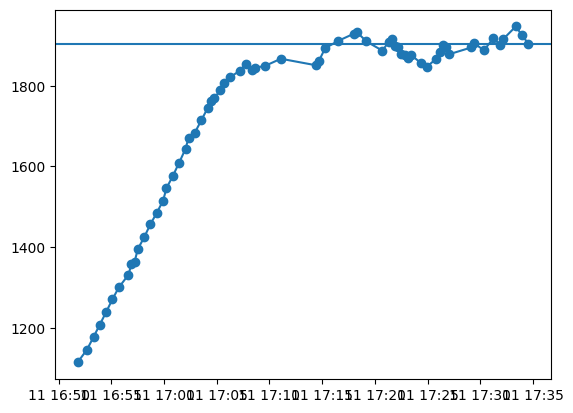

In [77]:
plt.plot(df_tu_trip_stop['feed_timestamp'], df_tu_trip_stop['arrival_delay'], marker='o', color='tab:blue', label='Arrival Delay')
plt.axhline(df_tu_trip_stop['arrival_delay'].iloc[-1])

In [90]:
df_vu_trip_trim['stop_id'].value_counts()

stop_id
140105    12
103069     8
140148     7
140101     4
103297     4
103201     4
103377     4
103125     4
103240     3
103321     3
103184     3
103385     3
103108     3
103171     3
103097     3
103392     2
140111     2
140245     2
140107     2
140259     2
103274     2
103375     2
103382     2
103365     2
103142     2
103221     2
140254     1
103260     1
Name: count, dtype: int64

In [30]:
df_stop = df_vu_trip[df_vu_trip['stop_id']=="140101"]

In [31]:
df_stop

,id,feed_timestamp,entity_id,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,position_latitude,position_longitude,position_bearing,...,position_speed,current_stop_sequence,current_status,timestamp,congestion_level,stop_id,vehicle_id,vehicle_label,trip_start_timestamp,read_timestamp


In [48]:
df_tu_trip

,id,feed_timestamp,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
0,7053,2026-01-11 23:00:27,2848729:11776521:11791827,0,8-KEL,1,1,140101,0,0,NaT,0,0,2026-01-12 00:50:00,0,2026-01-11 16:50:00
1,7054,2026-01-11 23:00:27,2848729:11776521:11791827,0,8-KEL,1,2,140105,0,0,2026-01-12 00:55:00,0,0,2026-01-12 00:55:00,0,2026-01-11 16:50:00
2,7055,2026-01-11 23:00:27,2848729:11776521:11791827,0,8-KEL,1,3,140107,0,0,2026-01-12 00:55:00,0,0,2026-01-12 00:55:00,0,2026-01-11 16:50:00
3,7056,2026-01-11 23:00:27,2848729:11776521:11791827,0,8-KEL,1,4,140259,0,0,2026-01-12 00:56:00,0,0,2026-01-12 00:56:00,0,2026-01-11 16:50:00
4,7057,2026-01-11 23:00:27,2848729:11776521:11791827,0,8-KEL,1,5,140111,0,0,2026-01-12 00:57:00,0,0,2026-01-12 00:57:00,0,2026-01-11 16:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127406,134459,2026-01-12 01:35:49,2848729:11776521:11791827,0,8-KEL,1,46,103030,0,193,2026-01-12 01:38:13,0,0,NaT,0,2026-01-11 16:50:00
127602,134655,2026-01-12 01:36:07,2848729:11776521:11791827,0,8-KEL,1,45,103020,0,199,2026-01-12 01:36:19,0,199,2026-01-12 01:36:19,0,2026-01-11 16:50:00
127603,134656,2026-01-12 01:36:07,2848729:11776521:11791827,0,8-KEL,1,46,103030,0,199,2026-01-12 01:38:19,0,0,NaT,0,2026-01-11 16:50:00
128064,135117,2026-01-12 01:36:43,2848729:11776521:11791827,0,8-KEL,1,46,103030,0,181,2026-01-12 01:38:01,0,0,NaT,0,2026-01-11 16:50:00


In [ ]:
df_trip_updates


In [9]:
df_tu_trip

,id,feed_timestamp,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp


In [8]:
df_vu_trip

,id,feed_timestamp,entity_id,trip_id,trip_schedule_relationship,trip_route_id,trip_direction_id,position_latitude,position_longitude,position_bearing,...,position_speed,current_stop_sequence,current_status,timestamp,congestion_level,stop_id,vehicle_id,vehicle_label,trip_start_timestamp,read_timestamp
0,1,2026-01-11 08:00:35,2,2847957:11777024:11791401,0,8-KEL,1,49.878010,-119.443352,180.399994,...,12.50,29,2,2026-01-11 08:00:28,1,103057,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:00:39
4,5,2026-01-11 08:00:50,2,2847957:11777024:11791401,0,8-KEL,1,49.877300,-119.444862,269.500000,...,13.05,29,2,2026-01-11 08:00:49,1,103057,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:00:55
8,9,2026-01-11 08:01:05,2,2847957:11777024:11791401,0,8-KEL,1,49.877312,-119.447609,270.299988,...,13.05,30,2,2026-01-11 08:01:05,1,103014,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:01:11
12,13,2026-01-11 08:01:21,2,2847957:11777024:11791401,0,8-KEL,1,49.877304,-119.450684,269.899994,...,13.61,30,2,2026-01-11 08:01:20,1,103014,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:01:26
16,17,2026-01-11 08:01:36,2,2847957:11777024:11791401,0,8-KEL,1,49.877281,-119.453461,268.799988,...,13.33,30,2,2026-01-11 08:01:35,1,103014,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:01:37
20,21,2026-01-11 08:01:51,2,2847957:11777024:11791401,0,8-KEL,1,49.877125,-119.456131,261.299988,...,12.50,30,0,2026-01-11 08:01:50,1,103014,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:01:52
24,25,2026-01-11 08:02:06,2,2847957:11777024:11791401,0,8-KEL,1,49.876972,-119.458099,261.299988,...,13.61,31,2,2026-01-11 08:02:02,1,102996,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:02:08
28,29,2026-01-11 08:02:21,2,2847957:11777024:11791401,0,8-KEL,1,49.876869,-119.462013,270.399994,...,13.88,32,0,2026-01-11 08:02:21,1,102986,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:02:23
32,33,2026-01-11 08:02:39,2,2847957:11777024:11791401,0,8-KEL,1,49.876888,-119.465050,269.200012,...,14.16,33,2,2026-01-11 08:02:36,1,102973,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:02:44
36,37,2026-01-11 08:02:54,2,2847957:11777024:11791401,0,8-KEL,1,49.877052,-119.468010,268.200012,...,15.55,34,2,2026-01-11 08:02:51,1,102950,3131329277,3131329277,2026-01-10 23:35:00,2026-01-11 08:02:54


In [ ]:


# Replace with your .shp file path
gdf = gpd.read_file(os.path.join(data_dir, "routes","routes.shp"))
gdf_8 = gdf[gdf['route_id'] == '8-KEL']

In [ ]:
df_8 = df_fetch[df_fetch['trip_route_id'] == '8-KEL']
df_8['stop_id'] = df_8['stop_id'].astype(int)
df_8 = pd.merge(df_8, df_bus_stop, left_on='stop_id', right_on='stopid', how='left', suffixes=(None, '_stop'))

In [ ]:
df_8_veh = df_8[df_8['vehicle_id'] == "3131329323"]
df_8['vehicle_id'].value_counts()

## Time between two stops

In [4]:
df_vehicle_updates['trip_route_id'].value_counts()

trip_route_id
97-KEL    18410
8-KEL     15938
11-KEL     8008
10-KEL     7477
98-KEL     6715
23-KEL     5540
1-KEL      5389
5-KEL      3689
16-KEL     3667
6-KEL      3392
20-KEL     2987
14-KEL     2806
18-KEL     2433
19-KEL     2412
24-KEL     2276
21-KEL     2071
22-KEL     1759
13-KEL     1386
2-KEL      1308
26-KEL     1186
84-KEL     1061
3-KEL       889
25-KEL      869
12-KEL      779
32-KEL      763
9-KEL       651
29-KEL      531
4-KEL       335
28-KEL      279
88-KEL      193
Name: count, dtype: int64

In [5]:
df_vu_bus = df_vehicle_updates[df_vehicle_updates['trip_route_id'] == '8-KEL']
#df_vu_bus = df_vehicle_updates[df_vehicle_updates['trip_route_id'] == '97-KEL']

In [6]:
df_vu_bus_filter = df_vu_bus[df_vu_bus['trip_direction_id']==1]

<Axes: xlabel='current_stop_sequence'>

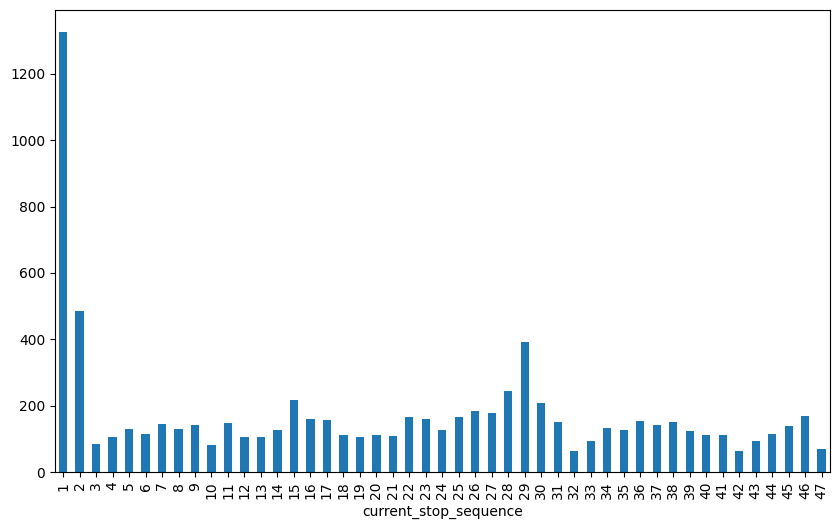

In [7]:
plt.figure(figsize=(10,6))
df_vu_bus_filter['current_stop_sequence'].value_counts(sort=False).sort_index().plot(kind='bar')

In [54]:
s1 = 10
s2 = 20
time_travel_between_stop_s1_and_s2 = []
time_stamps_s1 = []
trips = df_vu_bus_filter['trip_id'].unique().tolist()
for trip in trips:
    df_trip = df_vu_bus_filter[df_vu_bus_filter['trip_id'] == trip]
    stop_s1_time = df_trip[df_trip['current_stop_sequence'] == s1]['feed_timestamp'].dt.tz_localize('UTC').dt.tz_convert('America/Vancouver')
    stop_s2_time = df_trip[df_trip['current_stop_sequence'] == s2]['feed_timestamp'].dt.tz_localize('UTC').dt.tz_convert('America/Vancouver')
    if not stop_s1_time.empty and not stop_s2_time.empty:
        time_diff = (stop_s2_time.iloc[0] - stop_s1_time.iloc[-1]).total_seconds() 
        time_travel_between_stop_s1_and_s2.append(time_diff)
        time_stamps_s1.append(stop_s1_time.iloc[-1])
        

In [55]:
time_of_day_s1 =[ts.time().hour for ts in time_stamps_s1]
#time_of_day_s1 = np.array(time_of_day_s1)-8
#time_of_day_s1[time_of_day_s1<0] = time_of_day_s1[time_of_day_s1<0]+24

(0.0, 1200.0)

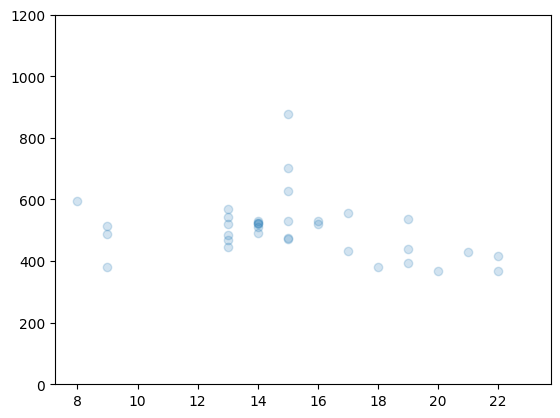

In [56]:
plt.scatter(time_of_day_s1, time_travel_between_stop_s1_and_s2, marker='o', alpha=0.2)
plt.ylim(0, 1200)

Text(0.5, 1.0, 'Time Travel Between Stop 10 and Stop 20')

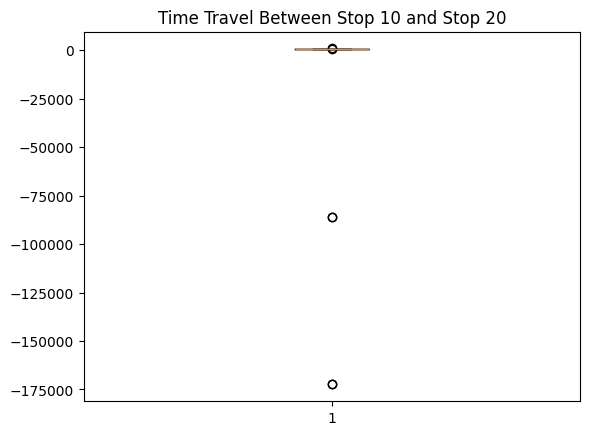

In [57]:
plt.boxplot(time_travel_between_stop_s1_and_s2)
plt.title(f'Time Travel Between Stop {s1} and Stop {s2}')

## Plots

### Stops

In [ ]:
df_stops = df_8.groupby('stop_id').first().reset_index()

In [ ]:
df_8_dir_0 = df_8[df_8['trip_direction_id'] == 0]
df_8_dir_1 = df_8[df_8['trip_direction_id'] == 1]


In [ ]:
df_dir_1_stop_seq = df_8_dir_1.groupby('current_stop_sequence')['stop_id'].value_counts().reset_index()
df_dir_0_stop_seq = df_8_dir_0.groupby('current_stop_sequence')['stop_id'].value_counts().reset_index()

In [ ]:
# check if stop id in df_dir_1_stop_seq are in df_dir_0_stop_seq
set_1 = set(df_dir_1_stop_seq['stop_id'].unique())
set_0 = set(df_dir_0_stop_seq['stop_id'].unique())
set_1 & set_0


In [ ]:
bool_unique_stop_per_sequence= df_dir_1_stop_seq['stop_id'].nunique() == len(df_dir_1_stop_seq)
print(f"Unique stop per sequence in direction 1: {bool_unique_stop_per_sequence}")
bool_unique_stop_per_sequence= df_dir_0_stop_seq['stop_id'].nunique() == len(df_dir_0_stop_seq)
print(f"Unique stop per sequence in direction 0: {bool_unique_stop_per_sequence}")

In [ ]:
df_stops_dir_0 = df_stops[df_stops['trip_direction_id'] == 0]
df_stops_dir_1 = df_stops[df_stops['trip_direction_id'] == 1]

In [ ]:

fig = go.Figure()

for i in range(len(gdf_8)):
    long, lat = gdf_8.iloc[i]['geometry'].xy
    long = list(long)
    lat = list(lat)
    fig.add_trace(go.Scattermap(
        lon=long,
        lat=lat,
        mode='lines',
        name=f'Segment {i+1}'
    ))

fig.add_trace(go.Scattermap(
    lon=df_stops_dir_0['longitude_stop'],
    lat=df_stops_dir_0['latitude_stop'],
    mode='markers',
    marker=go.scattermap.Marker(
        size=9,
        color='red'
    ),
    hovertext=df_stops_dir_0['current_stop_sequence'],
    name='Dir 0 Stop Locations'
))

fig.add_trace(go.Scattermap(
    lon=df_stops_dir_1['longitude_stop'],
    lat=df_stops_dir_1['latitude_stop'],
    mode='markers',
    marker=go.scattermap.Marker(
        size=9,
        color='blue'
    ),
    hovertext=df_stops_dir_1['current_stop_sequence'],
    name='Dir 1 Stop Locations'
))

fig.update_layout(
    map_style="open-street-map",
    map=dict(
        center=dict(lat=df_stops_dir_1['latitude_stop'].mean(), 
                    lon=df_stops_dir_1['longitude_stop'].mean()),
        zoom=11
    ),
    showlegend=True
)

fig.show()

### Time series

In [188]:

ts = df_8_veh.sort_values('read_timestamp')
# Use existing `ts` sorted by read_timestamp
fig_ts = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.05,
    subplot_titles=["Position Latitude", "Position Longitude", "Current Stop Sequence", "Trip Direction ID"]
)

fig_ts.add_trace(go.Scatter(
    x=ts['read_timestamp'], y=ts['position_latitude'],
    mode='lines+markers', name='Position Latitude'
), row=1, col=1)

fig_ts.add_trace(go.Scatter(
    x=ts['read_timestamp'], y=ts['position_longitude'],
    mode='lines+markers', name='Position Longitude'
), row=2, col=1)

fig_ts.add_trace(go.Scatter(
    x=ts['read_timestamp'], y=ts['current_stop_sequence'],
    mode='lines+markers', name='Current Stop Sequence'
), row=3, col=1)

fig_ts.add_trace(go.Scatter(
    x=ts['read_timestamp'], y=ts['trip_direction_id'],
    mode='lines+markers', name='Trip Direction ID'
), row=4, col=1)

fig_ts.update_yaxes(title_text='Position Latitude', row=1, col=1)
fig_ts.update_yaxes(title_text='Position Longitude', row=2, col=1)
fig_ts.update_yaxes(title_text='Current Stop Sequence', row=3, col=1)
fig_ts.update_yaxes(title_text='Trip Direction ID', row=4, col=1)
fig_ts.update_xaxes(title_text='Read Timestamp', row=4, col=1)

fig_ts.update_layout(height=900, showlegend=False)
fig_ts.show()


In [190]:
start_time = "2025-12-27 22:00:00"
end_time = "2025-12-27 22:35:00"

df_8_veh_time_filtered = df_8_veh[(df_8_veh['read_timestamp'] >= start_time) & (df_8_veh['read_timestamp'] <= end_time)]

In [191]:

ts = df_8_veh_time_filtered.sort_values('read_timestamp')
# Use existing `ts` sorted by read_timestamp
fig_ts = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.05,
    subplot_titles=["Position Latitude", "Position Longitude", "Current Stop Sequence", "Trip Direction ID"]
)

fig_ts.add_trace(go.Scatter(
    x=ts['read_timestamp'], y=ts['position_latitude'],
    mode='lines+markers', name='Position Latitude'
), row=1, col=1)

fig_ts.add_trace(go.Scatter(
    x=ts['read_timestamp'], y=ts['position_longitude'],
    mode='lines+markers', name='Position Longitude'
), row=2, col=1)

fig_ts.add_trace(go.Scatter(
    x=ts['read_timestamp'], y=ts['current_stop_sequence'],
    mode='lines+markers', name='Current Stop Sequence'
), row=3, col=1)

fig_ts.add_trace(go.Scatter(
    x=ts['read_timestamp'], y=ts['trip_direction_id'],
    mode='lines+markers', name='Trip Direction ID'
), row=4, col=1)

fig_ts.update_yaxes(title_text='Position Latitude', row=1, col=1)
fig_ts.update_yaxes(title_text='Position Longitude', row=2, col=1)
fig_ts.update_yaxes(title_text='Current Stop Sequence', row=3, col=1)
fig_ts.update_yaxes(title_text='Trip Direction ID', row=4, col=1)
fig_ts.update_xaxes(title_text='Read Timestamp', row=4, col=1)

fig_ts.update_layout(height=900, showlegend=False)
fig_ts.show()
